# Code

## Configuration & General

### Imports

In [24]:
from sklearn import set_config
set_config(transform_output="pandas")

import os
import pandas as pd
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from google.colab import drive

# --- CONFIGURATION & GLOBALS ---
drive.mount('content/')
plt.style.use("ggplot")

BASE_DIR = "content/MyDrive/Colab Notebooks/GP Datasets/"
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

MAIN_CSV_FILE = "25_countries_main.csv"
MAIN_CSV_PATH = os.path.join(BASE_DIR, MAIN_CSV_FILE)

Drive already mounted at content/; to attempt to forcibly remount, call drive.mount("content/", force_remount=True).


### Loading data

In [25]:
countries_ids = joblib.load(os.path.join(MODELS_DIR, "country_to_idx.joblib"))
ids_countries = joblib.load(os.path.join(MODELS_DIR, "idx_to_country.joblib"))

In [26]:
data_df = pd.read_csv(MAIN_CSV_PATH, parse_dates=['date'])

data_df['country_id'] = data_df['country_code'].map(countries_ids)

data_df.shape

(14100, 33)

## Preprocessing & Feature Engineering

### Helpers

In [27]:
# @title
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [28]:
# @title
class FeatureEngineerMixin(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X must be a pandas DataFrame")

        X_copy = X.copy()

        X_copy['date'] = pd.to_datetime(X_copy['date'])

        X_copy['day_of_week'] = X_copy['date'].dt.dayofweek
        X_copy['quarter'] = X_copy['date'].dt.quarter

        # Add Cyclic Encoding Transformations for dates and seasons.
        X_copy['month_sin'] = np.sin(2 * np.pi * X_copy['month'] / 12)
        X_copy['month_cos'] = np.cos(2 * np.pi * X_copy['month'] / 12)
        X_copy['week_sin'] = np.sin(2 * np.pi * X_copy['week'] / 52)
        X_copy['week_cos'] = np.cos(2 * np.pi * X_copy['week'] / 52)

        # A. Temporal Lags (The "Incubation Period")
        # We look back 1 week for pollution and temprature because diseases aren't instant.
        X_copy['pm25_ugm3_lag_1w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(1)
        X_copy['pm25_ugm3_lag_2w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(2)
        X_copy['pm25_ugm3_lag_4w'] = X_copy.groupby('country_code')['pm25_ugm3'].shift(4)

        X_copy['temp_lag_1w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(1)
        X_copy['temp_lag_2w'] = X_copy.groupby('country_code')['temperature_celsius'].shift(2)

        # B. Rolling Averages (The "Chronic Exposure")
        # B1. We calculate the average temperature of the last 4 weeks.
        X_copy['temp_2w_avg'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).mean())
        )

        # B2. Rolling standard deviation (volatility)
        X_copy['temp_2w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=2, min_periods=1).std())
        )

        X_copy['temp_4w_volatility'] = (
            X_copy.groupby('country_code')['temperature_celsius'].transform(lambda x: x.rolling(window=4, min_periods=1).std())
        )

        # C. Mathematical Transformations (Non-Linearity)
        # Temperature usually has a U-shaped effect on health (bad if too hot OR too cold)
        X_copy['temp_squared'] = X_copy['temperature_celsius'] ** 2

        # Log-Transform Target Variables
        # We do NOT scale this later.
        # X_copy['food_security_index_log'] = np.log1p(X_copy['food_security_index'])


        # D. Scientific Logic: The human body adapts to gradual change.
        # Sudden spikes (Thermal Shock) cause heart attacks and asthma attacks.
        # D1. We calculate: (Current Week Value) - (Last Week Value)
        X_copy['temp_change_rate'] = X_copy.groupby('country_code')['temperature_celsius'].diff()
        X_copy['pm25_change_rate'] = X_copy.groupby('country_code')['pm25_ugm3'].diff()
        X_copy['precip_change_rate'] = X_copy.groupby('country_code')['precipitation_mm'].diff()

        # E. Calculate Spatial Lag for Respiratory Disease
        # We take the average disease rate of the 5 neighbors (excluding the country itself)
        coords = X_copy[['latitude' , 'longitude']].values

        nbrs = NearestNeighbors(n_neighbors=5 , algorithm='ball_tree').fit(coords)
        distances , indices = nbrs.kneighbors(coords)

        neighbor_idx = indices[: , 1:] # Drop the first one (itself)

        X_copy['spatial_lag_pm25'] = X_copy['pm25_ugm3'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp'] = X_copy['temperature_celsius'].values[neighbor_idx].mean(axis=1)
        X_copy['spatial_lag_temp_anomaly'] = X_copy['temp_anomaly_celsius'].values[neighbor_idx].mean(axis=1)

        # F. The "Photochemical Smog" Effect
        # Scientific Logic: High heat catalyzes chemical reactions in pollutants (like Ozone/PM2.5), making them more toxic to the lungs.
        X_copy['pm25_temp_interaction'] = X_copy['pm25_ugm3'] * X_copy['temperature_celsius']
        X_copy['temp_precip_interaction'] = X_copy['temperature_celsius'] * X_copy['precipitation_mm']
        X_copy['pm25_precip_interaction'] = X_copy['pm25_ugm3'] * X_copy['precipitation_mm']

        # G. Hemisphere Indicators
        X_copy['is_northern'] = (X_copy['latitude'] > 0).astype(int)
        X_copy['is_tropical'] = (X_copy['latitude'].abs() < 23.5).astype(int)
        X_copy['distance_to_equator'] = X_copy['latitude'].abs()


        # I. The "Vulnerability" Effect
        # Scientific Logic: High pollution is manageable if Healthcare Access is high.
        # It becomes fatal if Healthcare is low.
        # We add a small epsilon (1e-6) to avoid division by zero.

        X_copy['pollution_vulnerability'] = X_copy['pm25_ugm3'] / (X_copy['healthcare_access_index'] + 1e-6)

        X_copy = X_copy.drop(columns=['month', 'week'])
        X_copy.fillna(X_copy.mean(numeric_only=True), inplace=True)

        self.feature_names_ = X_copy.columns.tolist()

        return X_copy

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return self.feature_names_

In [29]:
# @title
class CountryIQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, country_col='country_id', multiplier=1.5):
        self.country_col = country_col
        self.multiplier = multiplier

    def fit(self, X, y=None):
        self.feature_names_ = X.columns.tolist()
        self.bounds_ = {}

        for country in X[self.country_col].unique():
            mask = X[self.country_col] == country
            country_data = X.loc[mask, self.feature_names_]

            self.bounds_[country] = {}

            for col in self.feature_names_:
                if col == self.country_col: continue

                series = country_data[col].dropna()

                if len(series) < 10:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                Q1 = series.quantile(0.25)
                Q3 = series.quantile(0.75)
                IQR = Q3 - Q1

                if IQR == 0:
                    self.bounds_[country][col] = (series.min(), series.max())
                    continue

                lower = Q1 - self.multiplier * IQR
                upper = Q3 + self.multiplier * IQR
                self.bounds_[country][col] = (lower, upper)

        return self

    def transform(self, X):
        if not hasattr(self, 'bounds_'):
            raise ValueError("Capper has not been fitted yet. Call fit() first.")

        _X = X.copy()

        for country in _X[self.country_col].unique():
            mask = _X[self.country_col] == country

            if country not in self.bounds_:
                continue

            for col in self.feature_names_:
                if col == self.country_col: continue

                lower, upper = self.bounds_[country][col]
                _X.loc[mask, col] = _X.loc[mask, col].clip(lower=lower, upper=upper)

        return _X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_
        return input_features




In [30]:
# @title
class SelectiveStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, exclude_cols=None, drop_excluded=False):
        self.exclude_cols = exclude_cols or []
        self.drop_excluded = drop_excluded

    def fit(self, X, y=None):
        X = X.copy()

        self.scale_cols_ = [c for c in X.columns if c not in self.exclude_cols]

        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.scale_cols_])

        self.feature_names_in_ = X.columns.tolist()
        self.feature_names_out_ = self.scale_cols_ if self.drop_excluded else self.feature_names_in_

        return self

    def transform(self, X):
        X_copy = X.copy()

        X_copy[self.scale_cols_] = X_copy[self.scale_cols_].astype("float64")
        X_copy.loc[:, self.scale_cols_] = self.scaler_.transform(X_copy[self.scale_cols_])

        if self.drop_excluded:
            X_copy = X_copy[self.scale_cols_]

        return X_copy

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_out_)

### Pipeline

In [31]:
# @title
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Categorical features
categorical_ordinal = ['income_level']
categorical_onehot = ['region']

# Core numeric features (will be used to create engineered features)
core_numeric_features = [
    'country_id',
    'temperature_celsius', 'temp_anomaly_celsius',
    'pm25_ugm3', 'precipitation_mm',
    'food_security_index', 'population_millions',
    'air_quality_index', 'aqi_pm',
    'gdp_per_capita_usd', 'mental_health_index',
    'uhs_service_coverage_index',
]

# Engineered features (created by FeatureEngineerMixin)
engineered_features = [
    # PM2.5 lags and changes
    'pm25_ugm3_lag_1w', 'pm25_ugm3_lag_2w', 'pm25_ugm3_lag_4w',
    'pm25_change_rate',
    # Temperature lags and volatility
    'temp_lag_1w', 'temp_lag_2w',
    'temp_2w_volatility', 'temp_4w_volatility', 'temp_2w_avg',
    'temp_squared', 'temp_change_rate',
    # Precipitation
    'precip_change_rate',
    # Interactions
    'pm25_temp_interaction', 'pm25_precip_interaction',
    'temp_precip_interaction', 'pollution_vulnerability'
]

# Geographic/spatial features (likely from FeatureEngineerMixin)
spatial_features = [
    'latitude', 'longitude',
    'spatial_lag_pm25', 'spatial_lag_temp', 'spatial_lag_temp_anomaly',
    'is_northern', 'is_tropical', 'distance_to_equator'
]

# Environmental event indicators
event_features = [
    'heat_wave_days', 'drought_indicator',
    'flood_indicator', 'extreme_weather_events'
]

# Temporal features (from FeatureEngineerMixin)
temporal_features = [
    'day_of_week', 'quarter',
    'month_sin', 'month_cos', 'week_sin', 'week_cos'
]

# All numeric features that should be preprocessed
all_numeric_features = (
    core_numeric_features +
    engineered_features +
    spatial_features +
    event_features +
    temporal_features
)

# transform_features = [
#     'country_id',
#     'temperature_celsius', 'temp_anomaly_celsius',
#     'pm25_ugm3', 'precipitation_mm',
#     'food_security_index',

#     # Not in the feature_engineering_columns
#     'population_millions', 'air_quality_index', 'aqi_pm',
#     'gdp_per_capita_usd', 'mental_health_index', 'uhs_service_coverage_index',

#     # Engineered Features
#     'pm25_ugm3_lag_1w', 'pm25_ugm3_lag_2w', 'pm25_ugm3_lag_4w', 'pm25_change_rate',
#     'temp_lag_1w', 'temp_lag_2w', 'temp_2w_volatility', 'temp_4w_volatility',
#     'temp_2w_avg', 'temp_squared', 'temp_change_rate',
#     'precip_change_rate',
#     'pm25_temp_interaction', 'pm25_precip_interaction', 'temp_precip_interaction', 'pollution_vulnerability'
# ]

numeric_pipeline = Pipeline([
    ('capped', CountryIQRCapper()),
    # ('scaled', SelectiveStandardScaler(exclude_cols=['country_id'], drop_excluded=True)),
    ('knn_imputer', KNNImputer(n_neighbors=5)),
])

numeric_preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal_categorical', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_ordinal),
        ('onehot_categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_onehot),
        ('preprocessed', numeric_pipeline, all_numeric_features),
    ],
    verbose_feature_names_out=False,
    remainder='passthrough'
)

pipeline = Pipeline([
    ('date_feature_engineer', FeatureEngineerMixin()),
    ('numeric_preprocessing', numeric_preprocessor),
])

pipeline

Pipeline(steps=[('date_feature_engineer', FeatureEngineerMixin()),
                ('numeric_preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_categorical',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['income_level']),
                                                 ('onehot_categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['region']),
                                                 ('...
                                                   'pm25_ugm3_lag_2w',
                                                   'pm25_ugm3_lag_4w',
                                                   'pm25_change_rate',
                                                   'temp_lag_1w', 'temp_lag_2w',
                                                   'temp_2w_volatility',
                                                   'temp_4w_volatility',
                                                   'temp_2w_avg',
                                                   'temp_squared',
                                                   'temp_change_rate',
                                                   'precip_change_rate',
                                                   'pm25_temp_interaction',
                                                   'pm25_precip_interaction',
                                                   'temp_precip_interaction',
                                                   'pollution_vulnerability',
                                                   'latitude', 'longitude', ...])],
                                   verbose_feature_names_out=False))])

## Feature Selection

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import MultiTaskElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

targets = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions']
HELPER_COLS = ['record_id', 'country_code', 'country_name', 'income_level', 'date', 'year']

MISSING_RATIO_THRESHOLD = 0.3
CORR_THRESHOLD = 0.95
ELASTICNET_L1_RATIOS = [0.2, 0.5, 0.8]

RANDOM_STATE = 42

df = data_df.copy()

X = df.drop(columns=targets)
y = df[targets]

X_helpers = X[HELPER_COLS]
X_num = X.drop(columns=HELPER_COLS)

In [11]:
# ============================================================
# 1. SAFE PRE-FILTERING
# ============================================================

# ---- 1.1 Missing Value Filter
missing_ratio = X_num.isna().mean()
keep_missing = missing_ratio[missing_ratio <= MISSING_RATIO_THRESHOLD].index
X_num = X_num[keep_missing]

# ---- 1.2 Near-Zero Variance Filter
vt = VarianceThreshold(threshold=1e-4)
X_vt = vt.fit_transform(X_num)
vt_features = X_num.columns[vt.get_support()]
X_num = pd.DataFrame(X_vt, columns=vt_features, index=X_num.index)

# ---- 1.3 Extreme Correlation Filter
corr_matrix = X_num.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]
X_num = X_num.drop(columns=to_drop_corr)

print(f"After pre-filtering: {X_num.shape[1]} features")

After pre-filtering: 46 features


In [12]:
# ============================================================
# 2. SCALING
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

In [13]:
# ============================================================
# 3. MULTI-TASK ELASTIC NET (CORE STEP)
# ============================================================

enet = MultiTaskElasticNetCV(l1_ratio=ELASTICNET_L1_RATIOS, cv=TimeSeriesSplit(n_splits=5), random_state=RANDOM_STATE, max_iter=10000, n_jobs=-1)

enet.fit(X_scaled, y.values)

# ---- Coefficient aggregation across targets
coef_matrix = enet.coef_          # shape: (n_targets, n_features)
coef_norm = np.linalg.norm(coef_matrix, axis=0)

coef_df = (
    pd.DataFrame({'feature': X_num.columns, 'coef_l2_norm': coef_norm})
    .sort_values('coef_l2_norm', ascending=False)
    .reset_index(drop=True)
)

# ---- Threshold: non-zero + percentage
NON_ZERO_THRESHOLD = np.percentile(coef_norm[coef_norm > 0], 25)

selected_elasticnet = coef_df[coef_df['coef_l2_norm'] > NON_ZERO_THRESHOLD]['feature'].tolist()

print(f"ElasticNet selected {len(selected_elasticnet)} features")

ElasticNet selected 27 features


In [17]:
# ============================================================
# 4. PERMUTATION IMPORTANCE (VALIDATION)
# ============================================================

rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)

rf.fit(X_scaled.iloc[:, [X_num.columns.get_loc(f) for f in selected_elasticnet]], y.mean(axis=1))

perm = permutation_importance(
    rf,
    X_scaled.iloc[:, [X_num.columns.get_loc(f) for f in selected_elasticnet]],
    y.mean(axis=1),
    n_repeats=10,
    random_state=RANDOM_STATE
)

In [18]:
perm_df = (
    pd.DataFrame({'feature': selected_elasticnet, 'perm_importance_mean': perm.importances_mean})
    .sort_values('perm_importance_mean', ascending=False)
    .reset_index(drop=True)
)

# Keep features validated by BOTH
FINAL_THRESHOLD = perm_df['perm_importance_mean'].median()

selected_features_final = perm_df[perm_df['perm_importance_mean'] >= FINAL_THRESHOLD]['feature'].tolist()

print(f"PermutationImportance selected: {len(selected_features_final)} features")

feature_ranking_df = (
    coef_df
    .merge(perm_df, on='feature', how='left')
    .fillna(0)
    .sort_values(['coef_l2_norm', 'perm_importance_mean'], ascending=False)
    .reset_index(drop=True)
)

non_zero_features = feature_ranking_df[
    (feature_ranking_df['coef_l2_norm'] > 0) &
    (feature_ranking_df['perm_importance_mean'] > 0)
]

features = non_zero_features['feature'].tolist()
non_zero_features

PermutationImportance selected: 14 features


,feature,coef_l2_norm,perm_importance_mean
0,temp_squared,12.696194,0.052335
1,pm25_ugm3,5.781080,0.032172
2,heat_wave_days,4.297950,0.126531
3,month_sin,3.179860,0.035093
4,temp_precip_interaction,3.039181,0.046989
5,aqi_pm,2.300005,0.033808
6,temp_anomaly_celsius,2.182182,0.057347
7,pollution_vulnerability,2.028158,0.365104
8,flood_indicator,2.007762,0.005261
9,healthcare_access_index,1.613865,0.025308


## Skip Feature Selection

In [54]:
features = [
    # 'temperature_celsius', 'pm25_ugm3', 'heat_wave_days', 'aqi_pm',
    # 'healthcare_access_index', 'month', 'temp_anomaly_celsius',
    # 'flood_indicator', 'precipitation_mm', 'population_millions',
    # 'latitude', 'longitude',

    'temp_squared', 'pm25_ugm3', 'heat_wave_days', 'month_sin',
    'temp_precip_interaction', 'aqi_pm', 'temp_anomaly_celsius',
    'pollution_vulnerability', 'flood_indicator', 'healthcare_access_index',
    'distance_to_equator', 'pm25_change_rate', 'pm25_ugm3_lag_1w', 'month_cos',
    'temp_change_rate', 'temperature_celsius', 'gdp_per_capita_usd',
    'quarter', 'spatial_lag_pm25', 'is_northern',
    'is_tropical', 'spatial_lag_temp', 'food_security_index',
    # 'temp_squared', 'pm25_ugm3', 'heat_wave_days', 'month_sin',
    # 'temp_precip_interaction', 'aqi_pm', 'temp_anomaly_celsius',
    # 'pollution_vulnerability', 'flood_indicator', 'healthcare_access_index',
    # 'distance_to_equator', 'pm25_change_rate', 'pm25_ugm3_lag_1w', 'month_cos',
    # 'temp_change_rate', 'temperature_celsius', 'region_Oceania', 'gdp_per_capita_usd',
    # 'region_South Asia', 'region_Europe', 'quarter', 'spatial_lag_pm25', 'is_northern',
    # 'is_tropical', 'spatial_lag_temp', 'region_North America', 'food_security_index',
]

targets = ['respiratory_disease_rate', 'cardio_mortality_rate', 'vector_disease_risk_score', 'waterborne_disease_incidents', 'heat_related_admissions']

## Data Preparation Helpers

### TimeSeries Splitting

In [46]:
# @title
def ts_fold_split(df, k, min_train_years, val_years, test_years, year_col="year"):
    years = sorted(df[year_col].unique().tolist())

    min_years_needed = min_train_years + val_years + test_years
    assert len(years) >= min_years_needed, (
        f"Not enough unique years ({len(years)}) for "
        f"min_train_years={min_train_years}, "
        f"val_years={val_years}, "
        f"test_years={test_years}"
    )

    max_folds = len(years) - min_years_needed + 1
    k = min(k, max_folds)

    folds = []

    for i in range(k):
        train_end = min_train_years + i
        val_end = train_end + val_years
        test_end = val_end + test_years

        train_years = years[:train_end] # 0-3
        val_years_  = years[train_end:val_end] # 3-4
        test_years_ = years[val_end:test_end] # 4-5

        train_idx = df[df[year_col].isin(train_years)].index.tolist()
        val_idx   = df[df[year_col].isin(val_years_)].index.tolist()
        test_idx  = df[df[year_col].isin(test_years_)].index.tolist()

        if not train_idx or not val_idx or not test_idx:
            continue

        folds.append({
            "train_idx": train_idx,
            "val_idx": val_idx,
            "test_idx": test_idx,

            "train_years": train_years,
            "val_years": val_years_,
            "test_years": test_years_,
        })

    return folds

### Build Folds

In [47]:
def build_folds(df, features, targets, k=5, min_train_years=5, val_years=1, test_years=1):
    folds = []
    folds_info = ts_fold_split(df, k, min_train_years, val_years, test_years)

    for fold in folds_info:
        train_df = df.loc[fold["train_idx"]]
        val_df   = df.loc[fold["val_idx"]]
        test_df  = df.loc[fold["test_idx"]]

        train_df = pipeline.fit_transform(train_df)
        val_df   = pipeline.transform(val_df)
        test_df  = pipeline.transform(test_df)

        folds.append({
            "X_train": train_df[features], "y_train": train_df[targets],

            "X_val": val_df[features], "y_val": val_df[targets],

            "X_test": test_df[features], "y_test": test_df[targets],

            "train_years": fold["train_years"], "val_years": fold["val_years"], "test_years": fold["test_years"],
        })

    return folds

## Start Training Function

In [55]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor

def train_lgbm(fold, **lgbm_params):
    base_model = LGBMRegressor(**lgbm_params)

    model = MultiOutputRegressor(base_model)
    model.fit(fold["X_train"], fold["y_train"])

    return model

In [56]:
lgbm_params = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
}

folds = build_folds(df=data_df, features=features, targets=targets, k=4, min_train_years=2, val_years=3, test_years=3)

models = []

for i, fold in enumerate(folds, 1):
    print(f"Training fold {i} | Train years: {fold['train_years']} | Val years: {fold['val_years']} | Test years: {fold['test_years']}")

    model = train_lgbm(fold, **lgbm_params)
    models.append(model)


Training fold 1 | Train years: [2015, 2016] | Val years: [2017, 2018, 2019] | Test years: [2020, 2021, 2022]
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3342
[LightGBM] [Info] Number of data points in the train set: 2600, number of used features: 22
[LightGBM] [Info] Start training from score 69.970308
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000540 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3342
[LightGBM] [Info] Number of data points in the train set: 2600, number of used features: 22
[LightGBM] [Info] Start training from score 30.166462
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.037852 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `for

# Testing & Inference

### Testing on the test data loader

In [64]:
def ensemble_predict(models, fold):
    preds = [model.predict(fold['X_test']) for model in models]
    return np.mean(preds, axis=0), np.array(fold['y_test'])

all_preds, all_targets = ensemble_predict(models, folds[-1])

In [61]:
# Alternative baseline

def predict(model, fold):
    return model.predict(fold['X_test']), np.array(fold['y_test'])

all_preds, all_targets = predict(models[-1], folds[-1])

In [65]:
print(all_targets[-5:].tolist())
print(all_preds[-5:].tolist())

[[63.2, 20.2, 0.7, 21.9, 0.0], [83.8, 37.7, 6.2, 19.8, 0.0], [79.1, 31.5, 4.1, 16.2, 0.0], [56.5, 35.7, 11.2, 18.7, 0.0], [58.8, 28.5, 1.6, 15.9, 0.0]]
[[82.26353478533039, 31.52986393026304, 4.335301388683664, 22.137471881425085, -0.003054456082480679], [90.74693616760811, 32.93766666032141, 4.906102390658532, 23.607901176547728, -0.004270809950409182], [73.46641241636783, 30.966114335452534, 4.571612113250303, 20.96990363351598, -0.025231109600996306], [58.368426541731836, 28.1875585711548, 3.7008515952399637, 19.205803805270527, -0.05435711030475879], [58.98306051204401, 29.759498532863777, 4.1999884276278525, 20.041961594579085, 0.09687493039360055]]


In [ ]:
# Use these imports when loading via joblib.load
# from lightgbm import LGBMRegressor
# from sklearn.multioutput import MultiOutputRegressor

joblib.dump(models, os.path.join(MODELS_DIR, "[modelling_phase_v5]-lgbm_models.joblib"))

['content/MyDrive/Colab Notebooks/GP Datasets/models/[modelling_phase_v5]-lgbm_models.joblib']

### Calculate metrics per target.

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min() + 1e-8)
    return rmse, mae, r2, nrmse

def calculate_metrics(y_true, y_pred, save: bool = False):
    results = {}
    for i, target in enumerate(targets):
        rmse, mae, r2, nrmse = regression_metrics(y_true[:, i], y_pred[:, i])

        results[target] = {"RMSE": rmse, "MAE": mae, "R2": r2, "NRMSE_%": nrmse * 100}

    results_df = pd.DataFrame(results)
    macro_rmse = np.mean([results[t]["RMSE"] for t in targets])

    if save: results_df.to_csv("results.csv")

    return results_df, macro_rmse

results, overall_macro_rmse = calculate_metrics(all_targets, all_preds)

In [67]:
print(f"Overall Macro RMSE: {overall_macro_rmse}")
results

Overall Macro RMSE: 6.039178206009597


,respiratory_disease_rate,cardio_mortality_rate,vector_disease_risk_score,waterborne_disease_incidents,heat_related_admissions
RMSE,10.418765,5.264623,5.348469,5.207585,3.956449
MAE,8.357556,4.200537,3.540824,4.180093,2.551353
R2,0.540144,0.115816,0.906024,0.366118,0.830950
NRMSE_%,10.460607,13.395987,5.348469,8.679309,7.564911


### Visualization & Conclusion

> *Model performance was evaluated using RMSE, MAE, and NRMSE for each health outcome independently to account for scale differences across indicators. RMSE was emphasized due to its sensitivity to extreme health events such as heat-related admissions.*



In [69]:
y_true = all_targets
y_pred = all_preds

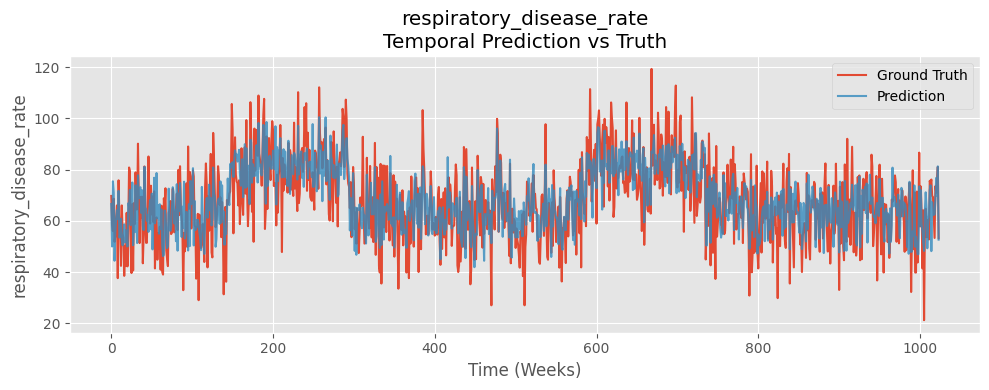

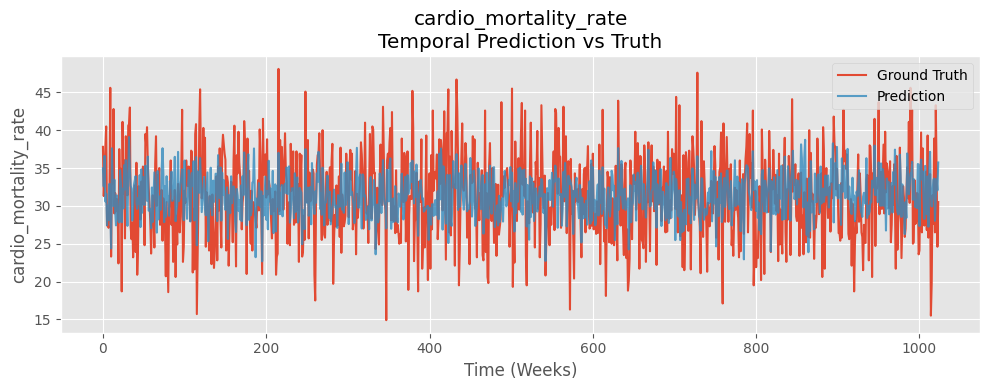

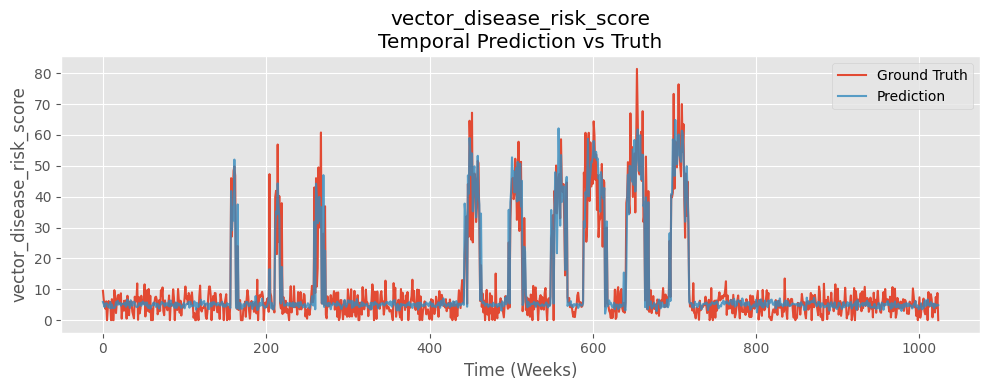

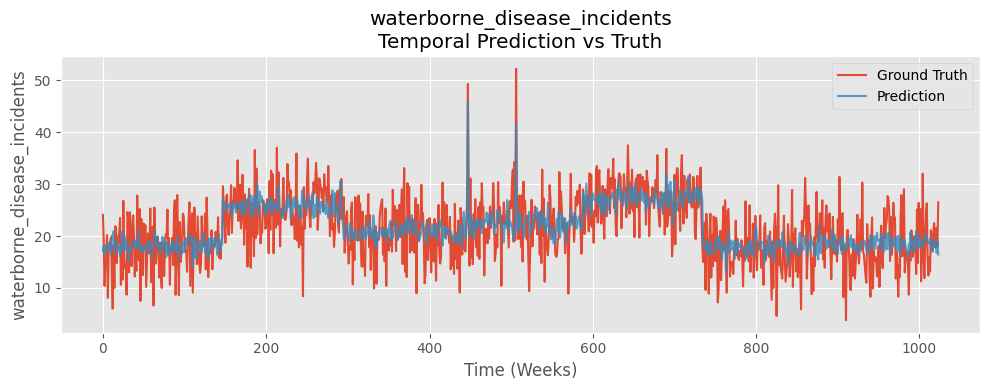

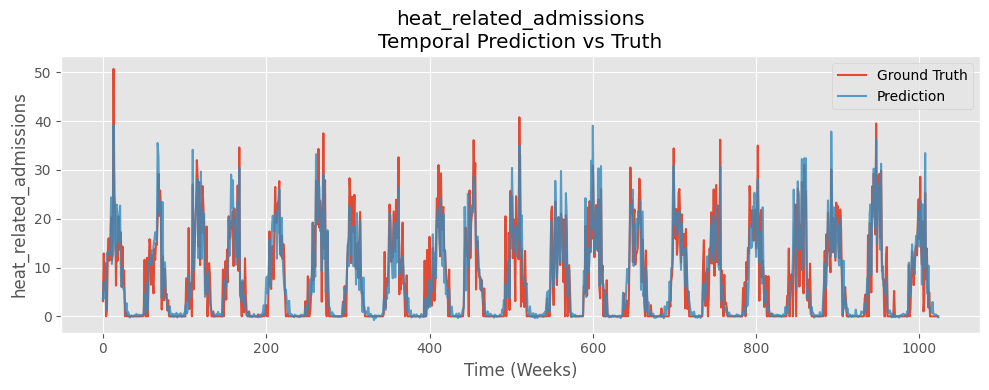

In [70]:
for i, target in enumerate(targets):

    plt.figure(figsize=(10, 4))

    plt.plot(y_true[:1024, i], label="Ground Truth")
    plt.plot(y_pred[:1024, i], label="Prediction", alpha=0.8)

    plt.xlabel("Time (Weeks)")
    plt.ylabel(target)
    plt.title(f"{target}\nTemporal Prediction vs Truth")
    plt.legend()

    plt.tight_layout()
    plt.show()



> *Residual-based visual diagnostics were used to assess model calibration, temporal consistency, and performance under extreme health events. Error dispersion increased during high-magnitude outcomes, highlighting the intrinsic difficulty of forecasting rare public-health spikes.*

